In [65]:
import os
print(os.getcwd())

/home/egork/Coding/hrt-datathon/yehor


In [72]:
import pandas as pd

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")

headlines_df = pd.read_parquet("../data/headlines_seen_train.parquet")
print(bars_df.columns)
print(bars_df.head())
print(headlines_df.columns)
print(headlines_df.head())

Index(['bar_ix', 'session', 'open', 'high', 'low', 'close'], dtype='object')
                 bar_ix  session  open    high     low   close
130065551606512       0        0   1.0  1.0029  0.9986  0.9999
96537894198480        0        1   1.0  1.0024  0.9980  1.0011
96537903350304        0        2   1.0  1.0005  0.9952  0.9957
96537894198480        0        3   1.0  1.0008  0.9986  1.0008
0                     0        4   1.0  1.0031  0.9996  1.0009
Index(['session', 'headline', 'bar_ix'], dtype='object')
                     session  \
 96537903172688            0   
 96537873208544            0   
 96537903172688            0   
 96537873208544            0   
-714663239826996203        0   

                                                              headline  bar_ix  
 96537903172688      Relvos Biosciences opens new office in Southea...       6  
 96537873208544      Orevex Renewables secures $500M contract with ...      12  
 96537903172688      Relvos Biosciences names new he

In [73]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_session_with_news(
    bars_df,
    headlines_df,
    session_n,
    price_col="close",
    figsize=(14, 6),
    show_headlines=True,
    rotate_labels=90,
):
    """
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
    """

    # Filter data
    bars = bars_df[bars_df["session"] == session_n].copy()
    news = headlines_df[headlines_df["session"] == session_n].copy()

    if bars.empty:
        print(f"No bars found for session {session_n}")
        return

    # Sort bars
    bars = bars.sort_values("bar_ix")
    news = news.sort_values("bar_ix")

    fig, ax = plt.subplots(figsize=figsize)

    # Plot price line
    ax.plot(
        bars["bar_ix"],
        bars[price_col],
        lw=2,
        label=f"{price_col.title()} Price"
    )

    # Vertical lines for headlines
    for _, row in news.iterrows():
        x = row["bar_ix"]

        ax.axvline(
            x=x,
            linestyle="--",
            alpha=0.6,
            linewidth=1
        )

        if show_headlines:
            ax.text(
                x,
                bars[price_col].max(),
                row["headline"],
                rotation=rotate_labels,
                va="top",
                ha="right",
                fontsize=8,
                alpha=0.8
            )

    ax.set_title(f"Session {session_n}: Price Movement + Headlines")
    ax.set_xlabel("bar_ix")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [74]:
# plot_session_with_news(bars_df, headlines_df, session_n=358)

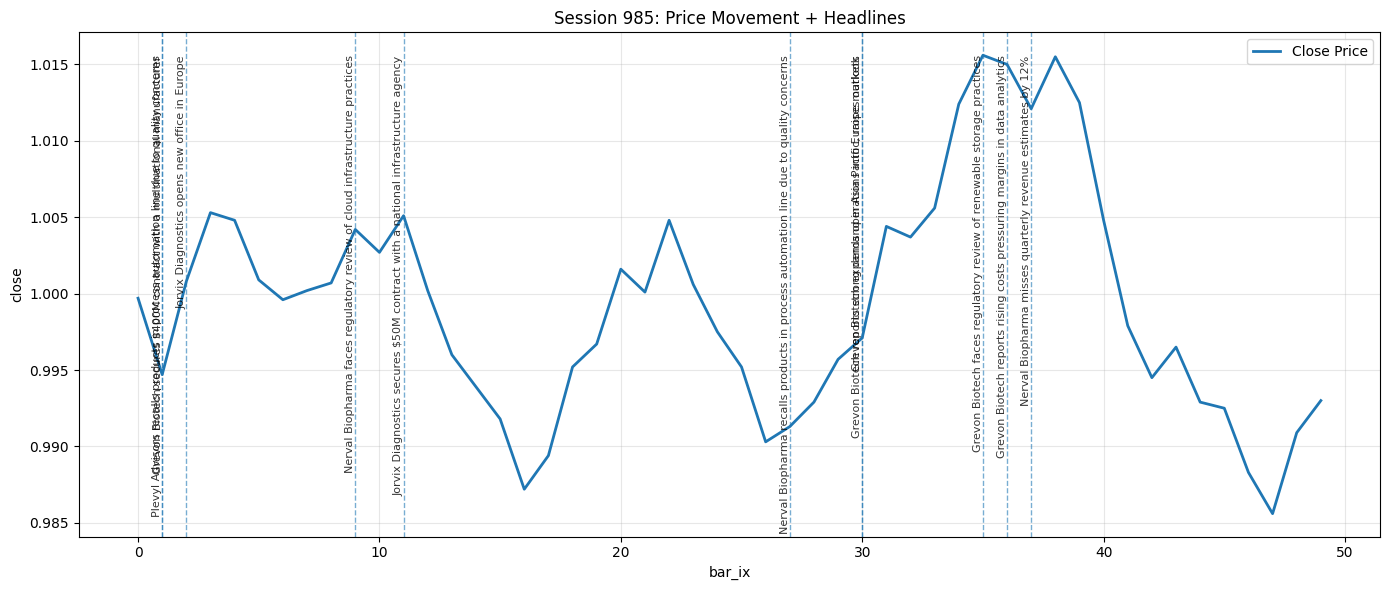

In [75]:
plot_session_with_news(bars_df, headlines_df, session_n=985)

In [76]:
from collections import Counter


df = headlines_df.copy()
print(df.columns)

words = []
companies = []
companies_to_sessions = {}

for row in df.itertuples(index=False):
    # print(row)
    headline = row.headline
    session = int(row.session)

    words_in_headline = headline.split()
    company = words_in_headline[0] + words_in_headline[1]
    companies.append(company)
    if company not in companies_to_sessions:
        companies_to_sessions[company] = set()
    companies_to_sessions[company].add(session)
    for i in range(2, len(words_in_headline)):
        words.append(words_in_headline[i])



counts = dict(Counter(words))


for key, value in sorted(counts.items(), key=lambda item: item[1]):
    print(f"{key}: {value}")

counts_companies = dict(Counter(companies))
print("=" * 60)
for key, value in sorted(counts_companies.items(), key=lambda item: item[1]):
    print(f"{key}: {value}")
print("+" * 60)

for key, value in companies_to_sessions.items():
    print(f"{key}: {value}")

Index(['session', 'headline', 'bar_ix'], dtype='object')
board: 11
discuss: 11
initiative: 11
$6.3B: 13
Asia,: 17
publishes: 19
sustainability: 19
report: 19
$8.4B: 20
schedules: 20
shareholder: 20
next: 20
month: 20
East,: 20
$1.2B: 21
beats: 22
analyst: 22
expectations: 22
earnings: 22
growth: 22
$0.8B: 22
$4.1B: 23
lowers: 23
amid: 23
softening: 23
Pacific,: 23
talks: 23
potential: 23
merger,: 23
details: 23
undisclosed: 23
plan,: 24
cites: 24
challenging: 24
achieves: 25
milestone: 25
ahead: 25
schedule: 25
$2.5B: 25
organizational: 26
$7.9B: 27
$3.8B: 27
robust: 27
Scandinavia,: 28
$5.7B: 28
meeting: 31
$9.6B: 33
Europe,: 38
annual: 39
Annual: 39
Industry: 39
CEO: 40
CTO: 40
Tech: 42
Leadership: 42
Conference: 42
Global: 48
Innovation: 48
Summit: 48
Emerging: 50
restructuring: 50
full-year: 50
guidance: 50
America,: 51
Corporate: 53
Symposium: 53
CFO: 55
Capital: 56
Day: 56
Operating: 60
Forum: 89
Strategy: 102
Markets: 106
Chief: 109
Officer: 109
steps: 112
down: 112
unexpectedly

In [ ]:
import itertools
import numpy as np
from sklearn.cluster import AgglomerativeClustering


companies = companies_to_sessions
names = list(companies.keys())

# --- Jaccard distance matrix ---
def jaccard(a, b):
    return 1 - len(a & b) / len(a | b)

n = len(names)
dist_matrix = np.zeros((n, n))

for i, j in itertools.product(range(n), range(n)):
    if i != j:
        dist_matrix[i][j] = jaccard(companies[names[i]], companies[names[j]])

# --- clustering ---
model = AgglomerativeClustering(
    metric="precomputed",
    linkage="average",
    n_clusters=None,
    distance_threshold=0.7  # tune this
)

labels = model.fit_predict(dist_matrix)

# group results
clusters = {}
for name, label in zip(names, labels):
    clusters.setdefault(label, []).append(name)


print(clusters)

{np.int64(52): ['RelvosBiosciences'], np.int64(59): ['OrevexRenewables'], np.int64(67): ['CalvisSciences'], np.int64(57): ['YorvovPharmaceuticals'], np.int64(49): ['StrynalIndustries'], np.int64(63): ['JorvisFuels'], np.int64(56): ['ZrovexIndustries'], np.int64(51): ['HalvavBrands'], np.int64(79): ['KelvikPower'], np.int64(60): ['ZelvalEnergy'], np.int64(48): ['KrevanInvestments'], np.int64(29): ['TalvixHoldings'], np.int64(78): ['RelvanSoftware'], np.int64(64): ['PlevepPower'], np.int64(77): ['FrelolSoftware'], np.int64(65): ['CrevenSecurities'], np.int64(31): ['NolvolResources'], np.int64(42): ['UrvelGrid'], np.int64(69): ['UlvonRenewables'], np.int64(75): ['HalvixHoldings'], np.int64(70): ['HoltarStores'], np.int64(73): ['NolvavCommerce'], np.int64(66): ['MyrnepTechnologies'], np.int64(76): ['JovalBrands'], np.int64(32): ['BrevepSystems'], np.int64(39): ['IlvalFinancial'], np.int64(55): ['PlevumPartners'], np.int64(37): ['ErvanCapital'], np.int64(46): ['OrevovSolutions'], np.int64(1

In [ ]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(dist_matrix, index=names, columns=names)

# reorder by cluster label
order = np.argsort(labels)
df = df.iloc[order, order]

plt.figure(figsize=(10, 8))
ssns.heatmap(df, cmap="viridis", annot=False)aaa

plt.title("Jaccard Distance Heatmap (Clustered Order)")
plt.tight_layout()
plt.show()